<a href="https://colab.research.google.com/github/nayonski/Project/blob/main/Bangladesh_Rainfall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Read dataset.csv file

In [2]:
df = pd.read_csv("/content/BD_weather.csv")
df.head(15)

,Station,Year,Month,Day,Rainfall,Sunshine,Humidity,Temperature
0,Ambaganctg,2008,1,1,0.0,9.1,78.0,20.1
1,Ambaganctg,2008,1,2,0.0,5.6,79.0,21.0
2,Ambaganctg,2008,1,3,0.0,8.6,82.0,20.1
3,Ambaganctg,2008,1,4,0.0,9.1,73.0,21.0
4,Ambaganctg,2008,1,5,0.0,9.4,67.0,20.3
5,Ambaganctg,2008,1,6,0.0,9.6,69.0,20.1
6,Ambaganctg,2008,1,7,0.0,9.2,76.0,20.8
7,Ambaganctg,2008,1,8,0.0,9.3,74.0,21.1
8,Ambaganctg,2008,1,9,0.0,8.4,77.0,20.6
9,Ambaganctg,2008,1,10,0.0,9.1,77.0,21.1


Specific series of row showing from original dataset

In [3]:
df.iloc[3500:3520]

,Station,Year,Month,Day,Rainfall,Sunshine,Humidity,Temperature
3500,Ambaganctg,2017,8,1,0.0,3.9,83.0,29.5
3501,Ambaganctg,2017,8,2,0.0,4.9,84.0,29.3
3502,Ambaganctg,2017,8,3,0.0,7.2,83.0,29.7
3503,Ambaganctg,2017,8,4,0.0,8.1,81.0,29.6
3504,Ambaganctg,2017,8,5,0.0,6.4,84.0,29.2
3505,Ambaganctg,2017,8,6,0.0,1.5,86.0,28.7
3506,Ambaganctg,2017,8,7,9.0,0.5,86.0,28.5
3507,Ambaganctg,2017,8,8,8.0,1.7,87.0,28.3
3508,Ambaganctg,2017,8,9,12.0,4.1,89.0,27.9
3509,Ambaganctg,2017,8,10,14.0,0.0,92.0,27.3


Cleaning the ordered data

In [4]:
df.drop(df[(df['Day']>28) & (df['Month']==2) & (df['Year']%4!=0)].index,inplace=True)
df.drop(df[(df['Day']>29) & (df['Month']==2) & (df['Year']%4==0)].index,inplace=True)
df.drop(df[(df['Day']>30) & ((df['Month']==4)|(df['Month']==6)|(df['Month']==9)|(df['Month']==11))].index,inplace=True)

Clean the columns and showing

In [5]:
#making a new dataframe
df_new = df.drop(columns= ["Temperature","Humidity","Sunshine"])
print(df_new.head())

      Station  Year  Month  Day  Rainfall
0  Ambaganctg  2008      1    1       0.0
1  Ambaganctg  2008      1    2       0.0
2  Ambaganctg  2008      1    3       0.0
3  Ambaganctg  2008      1    4       0.0
4  Ambaganctg  2008      1    5       0.0


Specific series of row showing from new dataframe

In [6]:

df_new.iloc[20000:20020]

,Station,Year,Month,Day,Rainfall
20000,Barisal,2005,10,4,105.0
20001,Barisal,2005,10,5,4.0
20002,Barisal,2005,10,6,0.0
20003,Barisal,2005,10,7,0.0
20004,Barisal,2005,10,8,0.0
20005,Barisal,2005,10,9,0.0
20006,Barisal,2005,10,10,0.0
20007,Barisal,2005,10,11,0.0
20008,Barisal,2005,10,12,0.0
20009,Barisal,2005,10,13,0.0


Indexing new columns through combining columns

In [7]:
df_new['Date'] = pd.to_datetime(df_new[['Year', 'Month', 'Day']])
df_new.set_index('Date', inplace=True)

In [8]:
df_new.head()

,Station,Year,Month,Day,Rainfall
Date,,,,,
2008-01-01,Ambaganctg,2008,1,1,0.0
2008-01-02,Ambaganctg,2008,1,2,0.0
2008-01-03,Ambaganctg,2008,1,3,0.0
2008-01-04,Ambaganctg,2008,1,4,0.0
2008-01-05,Ambaganctg,2008,1,5,0.0


Indexing new columns

In [9]:
df_new['dayofyear'] = df_new.index.dayofyear
df_new['month'] = df_new.index.month
df_new['year'] = df_new.index.year
df_new['weekday'] = df_new.index.day_name()   # Monday, Tuesday...


In [10]:
df_new.head()

,Station,Year,Month,Day,Rainfall,dayofyear,month,year,weekday
Date,,,,,,,,,
2008-01-01,Ambaganctg,2008,1,1,0.0,1,1,2008,Tuesday
2008-01-02,Ambaganctg,2008,1,2,0.0,2,1,2008,Wednesday
2008-01-03,Ambaganctg,2008,1,3,0.0,3,1,2008,Thursday
2008-01-04,Ambaganctg,2008,1,4,0.0,4,1,2008,Friday
2008-01-05,Ambaganctg,2008,1,5,0.0,5,1,2008,Saturday


In [11]:
df_new.iloc[300000:300010]

,Station,Year,Month,Day,Rainfall,dayofyear,month,year,weekday
Date,,,,,,,,,
2001-05-21,Kutubdia,2001,5,21,26.0,141,5,2001,Monday
2001-05-22,Kutubdia,2001,5,22,0.0,142,5,2001,Tuesday
2001-05-23,Kutubdia,2001,5,23,5.0,143,5,2001,Wednesday
2001-05-24,Kutubdia,2001,5,24,5.0,144,5,2001,Thursday
2001-05-25,Kutubdia,2001,5,25,17.0,145,5,2001,Friday
2001-05-26,Kutubdia,2001,5,26,0.0,146,5,2001,Saturday
2001-05-27,Kutubdia,2001,5,27,0.0,147,5,2001,Sunday
2001-05-28,Kutubdia,2001,5,28,0.0,148,5,2001,Monday
2001-05-29,Kutubdia,2001,5,29,0.0,149,5,2001,Tuesday


Monthly Rainfall pattern

In [12]:
monthly_rainfall = df_new.groupby(['Station','year','month'])['Rainfall'].mean()
monthly_rainfall.head()

Station     year  month
Ambaganctg  2008  1        1.806452
                  2        0.448276
                  3        0.451613
                  4        0.033333
                  5        8.774194
Name: Rainfall, dtype: float64

Yearly Rainfall Pattern

In [13]:
yearly_rainfall = df_new.groupby(['Station','year'])['Rainfall'].sum()
yearly_rainfall.head()


Station     year
Ambaganctg  2008    3344.0
            2009    3110.0
            2010    2397.0
            2011    3150.0
            2012    3275.0
Name: Rainfall, dtype: float64

Daily rainfall trends in Dhaka

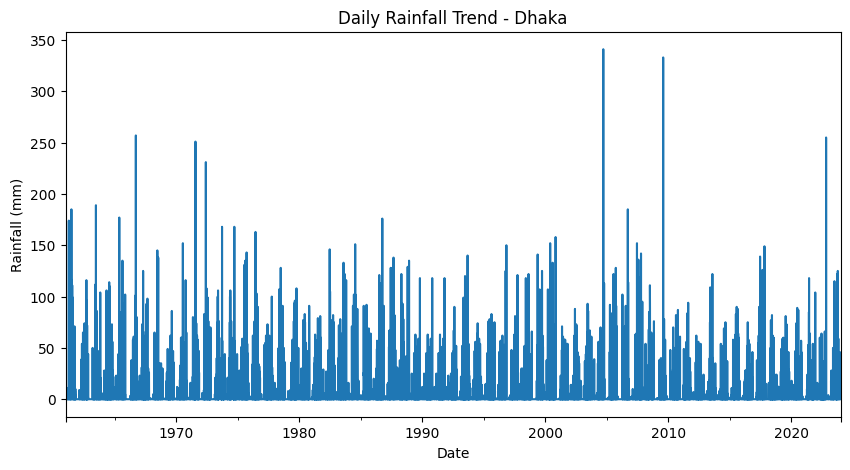

In [14]:
# Plot daily rainfall trend for one station
df_new[df_new['Station']=='Dhaka'].groupby('Date')['Rainfall'].sum().plot(figsize=(10,5))
plt.title("Daily Rainfall Trend - Dhaka")
plt.ylabel("Rainfall (mm)")
plt.show()


Daily rainfall trend in Sylhet

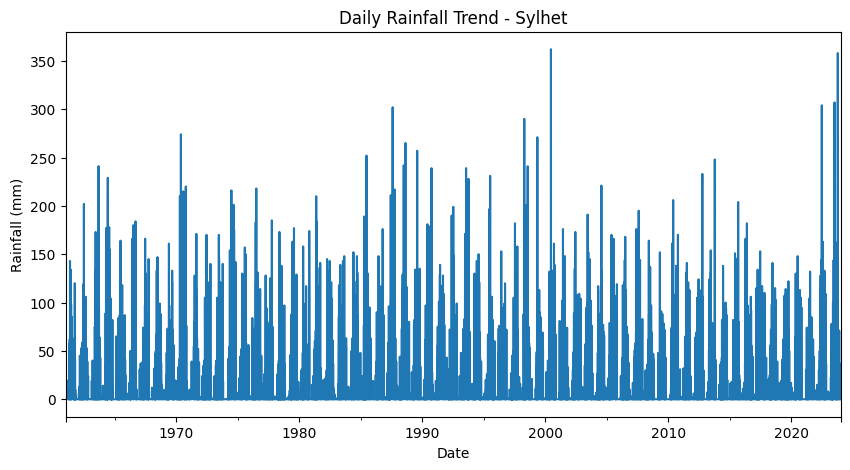

In [15]:
# Plot daily rainfall trend for one station
df_new[df_new['Station']=='Sylhet'].groupby('Date')['Rainfall'].sum().plot(figsize=(10,5))
plt.title("Daily Rainfall Trend - Sylhet")
plt.ylabel("Rainfall (mm)")
plt.show()

Rainfall pattern of 6 stations showing by bar plot

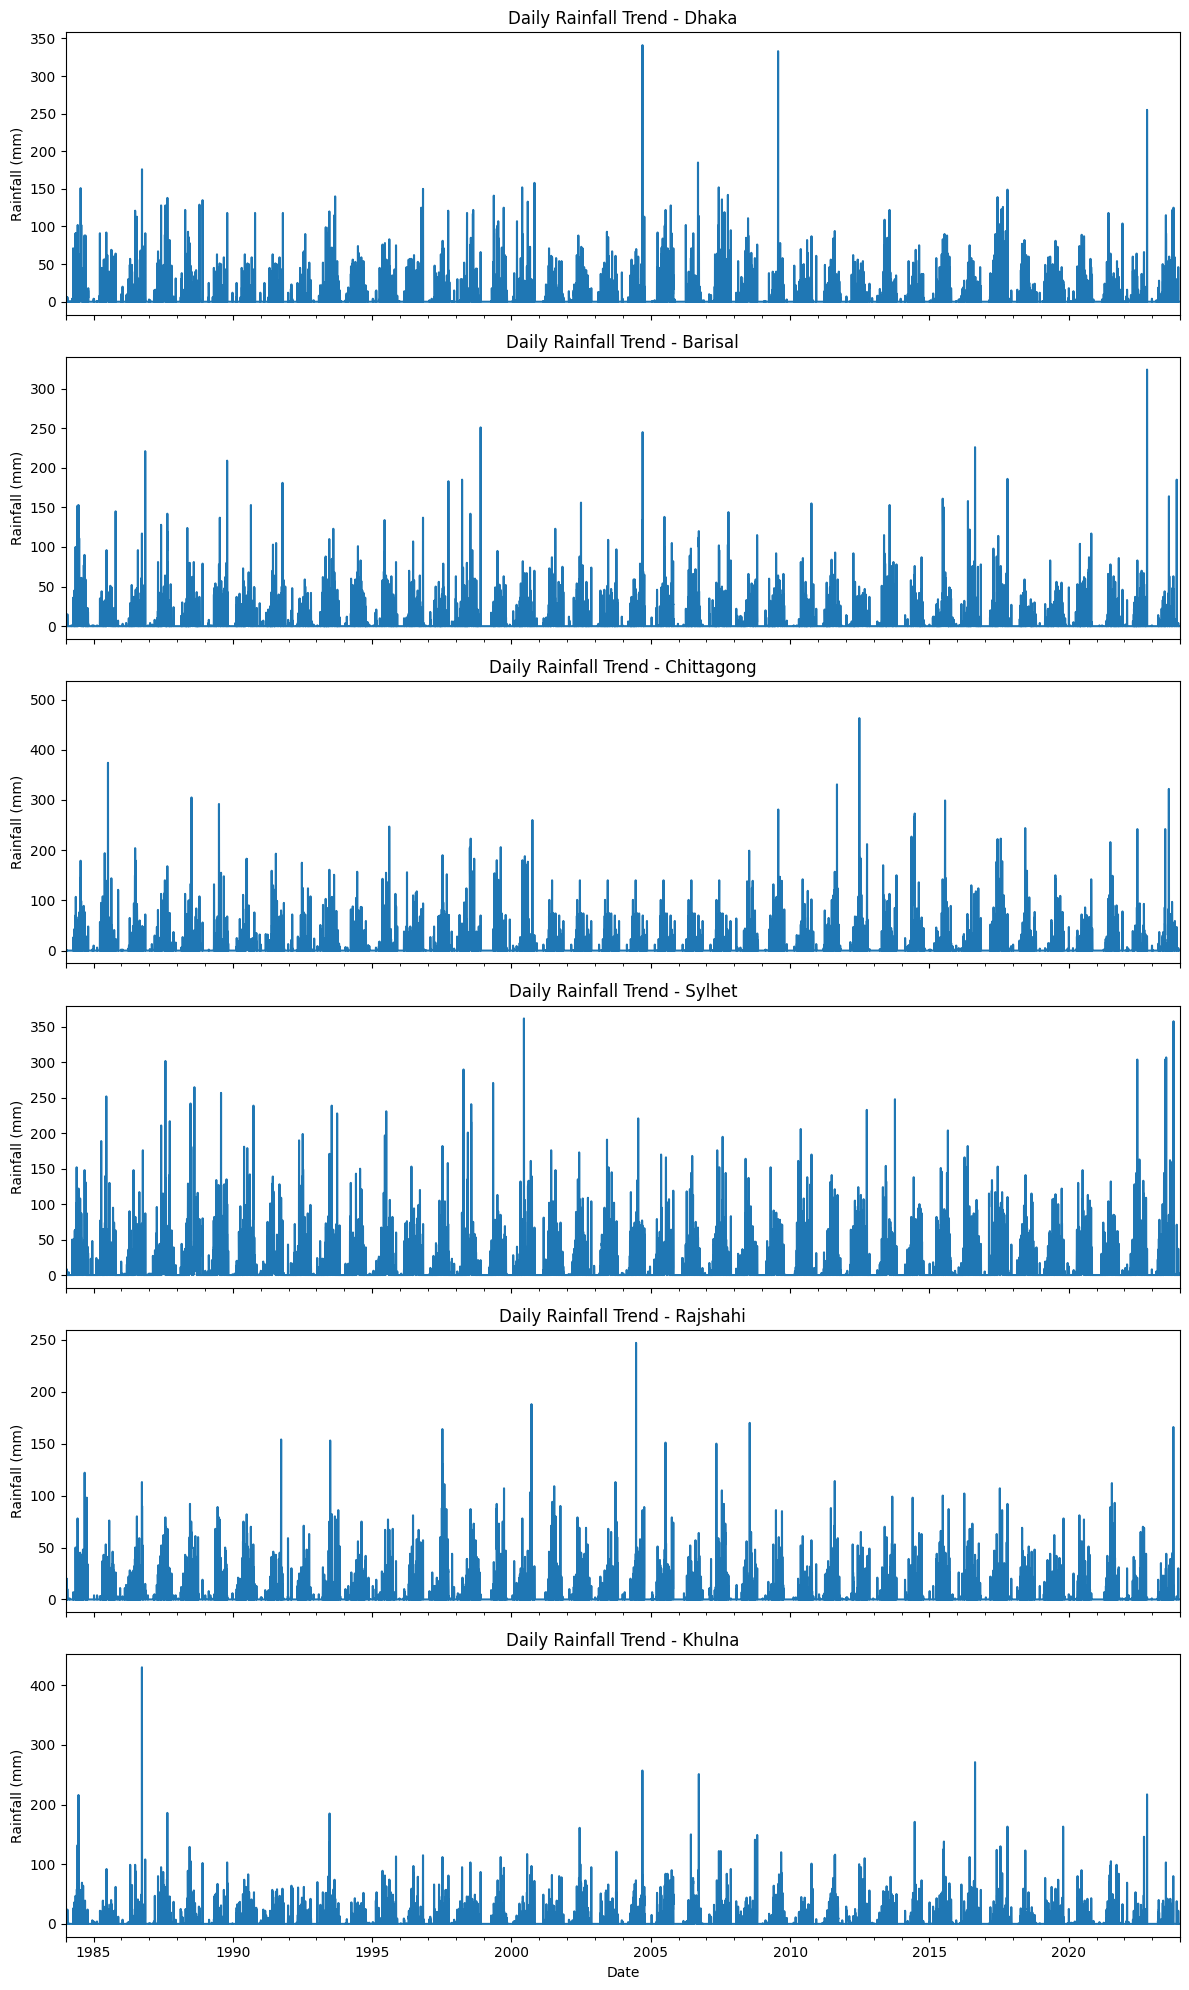

In [16]:
stations = ['Dhaka', 'Barisal', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna']

# Create subplots: 6 rows, 1 column
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 20), sharex=True)

# Loop through each station and plot on separate subplot
for i, station in enumerate(stations):
    ax = axes[i]
    (df_new[df_new['Station'] == station]
         .groupby('Date')['Rainfall']
         .sum()
         .plot(ax=ax))

    ax.set_title(f"Daily Rainfall Trend - {station}")
    ax.set_ylabel("Rainfall (mm)")

plt.xlabel("Date")
plt.tight_layout()
plt.show()


Individual rainfall pattern showing by using scatter plot

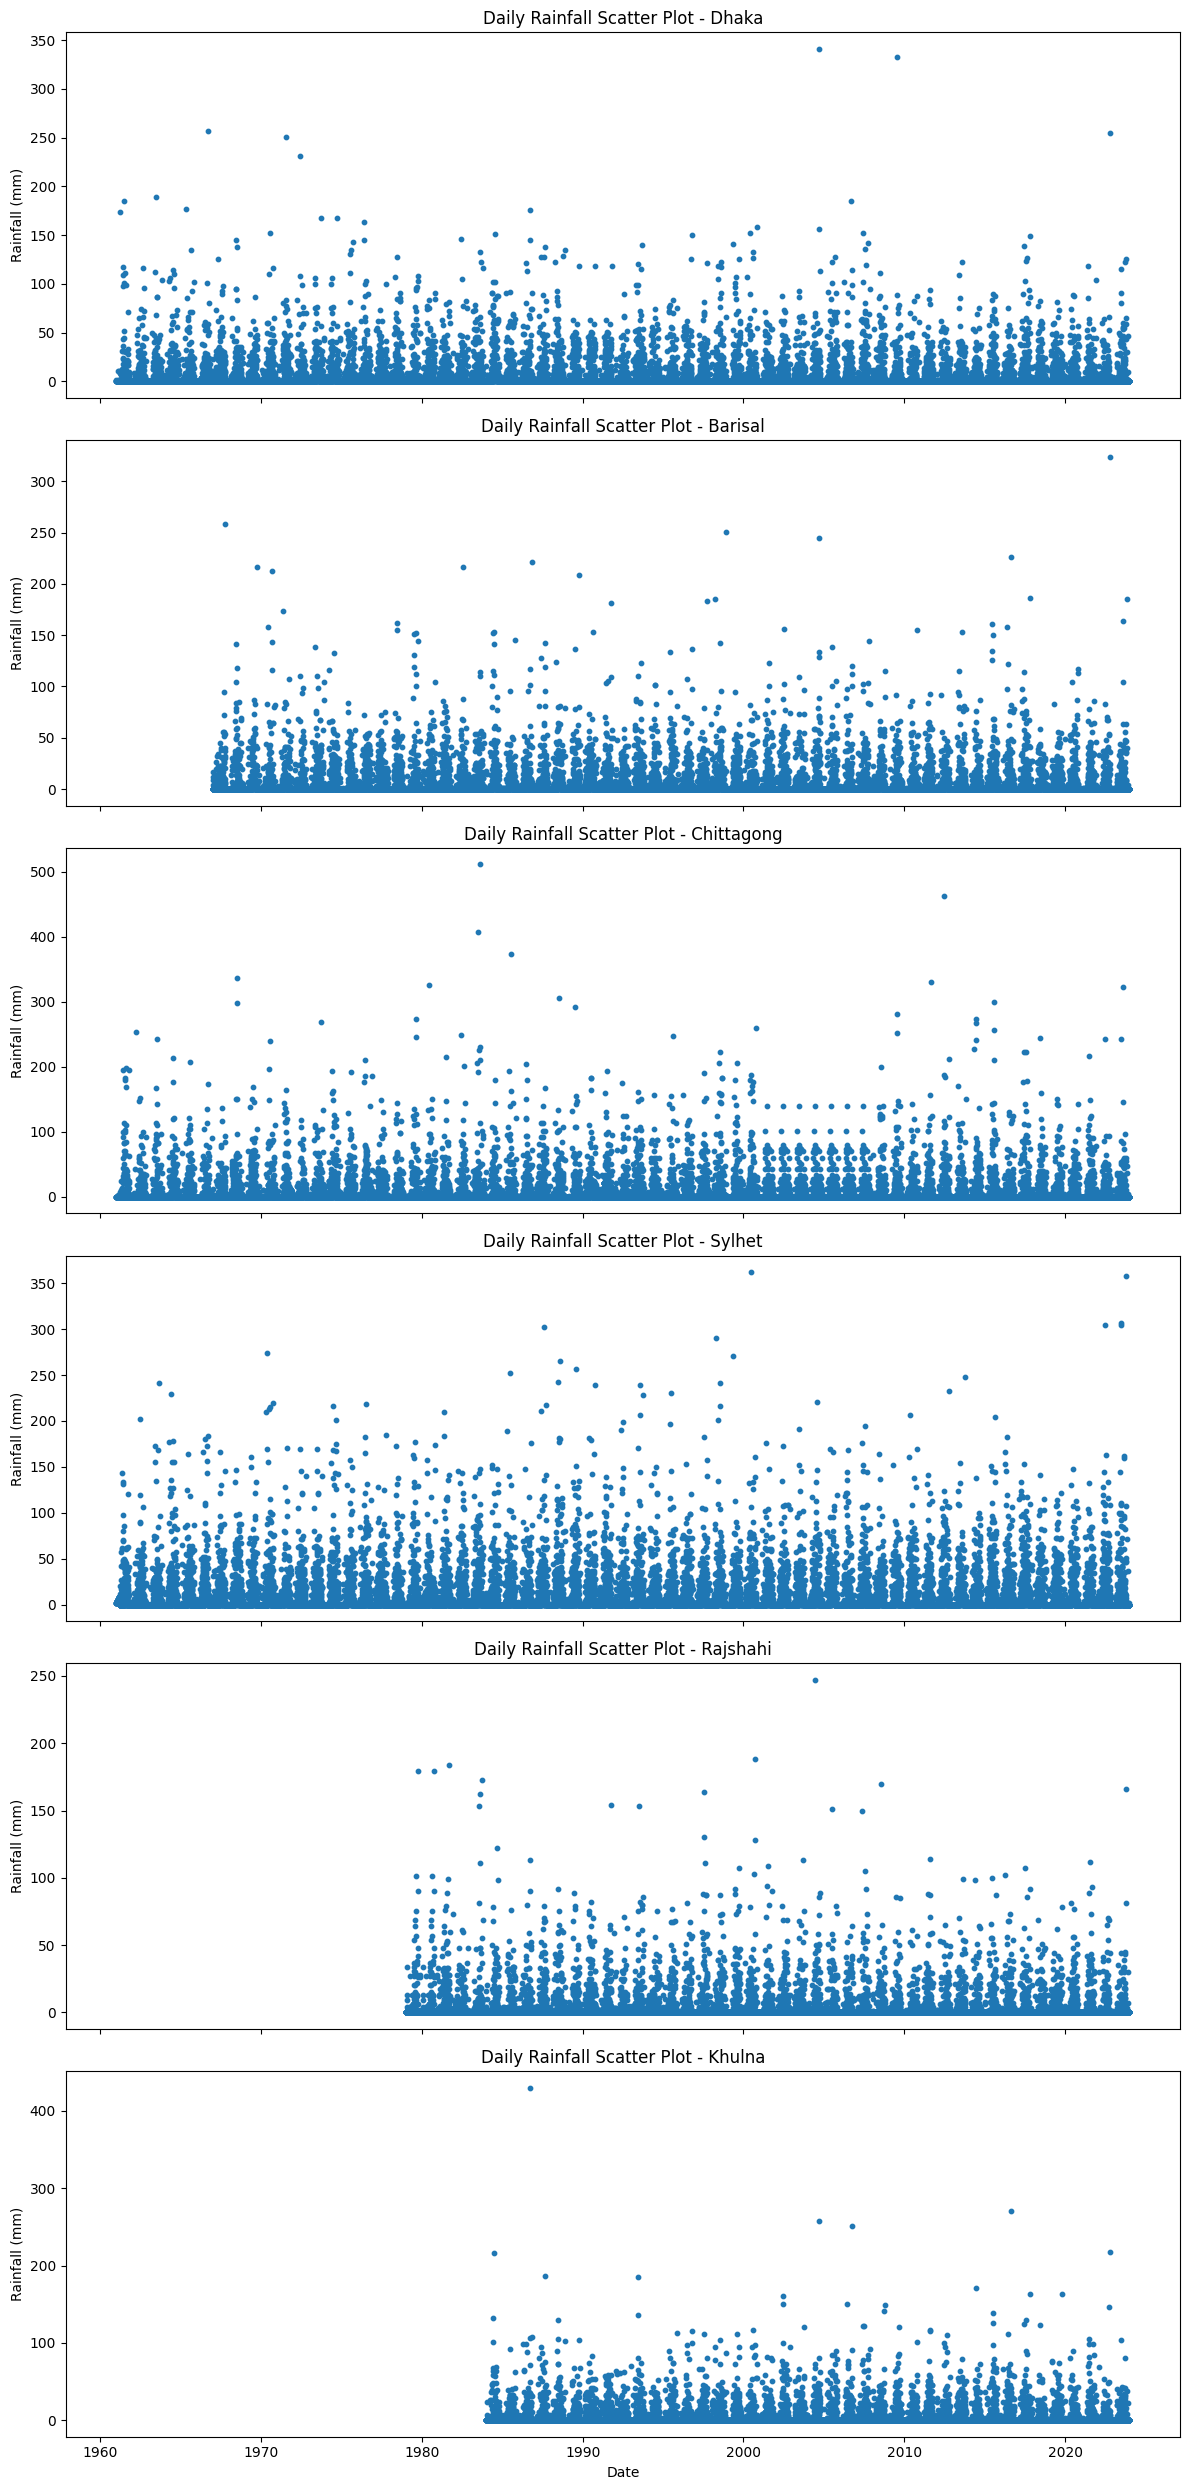

In [17]:
# Select the stations you want
stations = ['Dhaka', 'Barisal', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna']

# Create subplots: 6 rows, 1 column
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 25), sharex=True)
# Loop through each station and plot on separate subplot
for i, station in enumerate(stations):
    ax = axes[i]
    df_station = df_new[df_new['Station'] == station].groupby('Date')['Rainfall'].sum()

    ax.scatter(df_station.index, df_station, s=10)  # s=10 controls dot size
    ax.set_title(f"Daily Rainfall Scatter Plot - {station}")
    ax.set_ylabel("Rainfall (mm)")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

Rainfall pattern of 6 station's showing by scatter plot

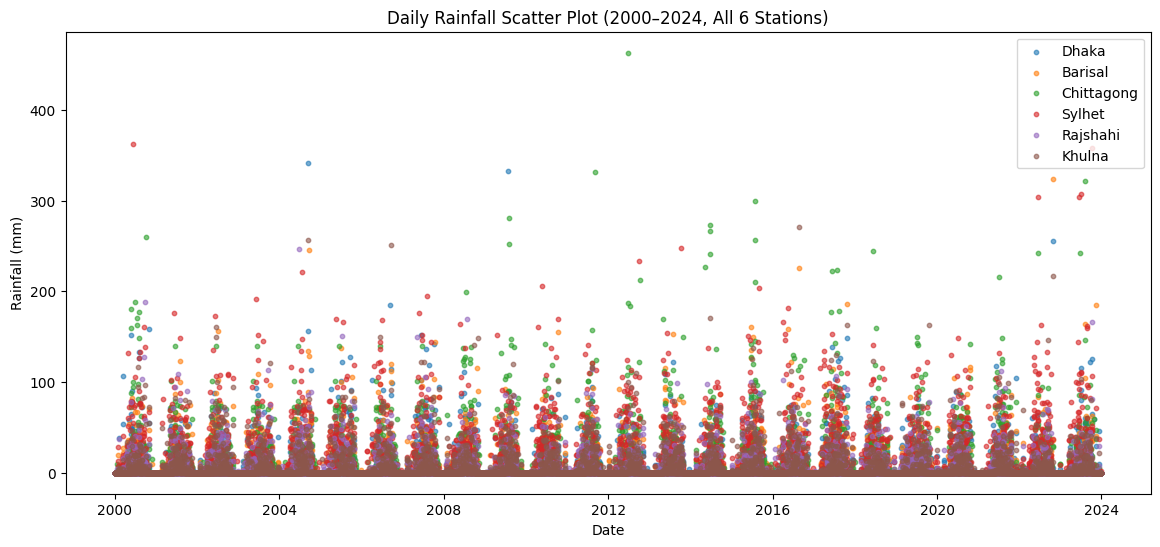

In [18]:
stations = ['Dhaka', 'Barisal', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna']

# Filter the dataframe for 2010–2024
df_fil = df_new[(df_new['year'] >= 2000) & (df_new['year'] <= 2024)]

plt.figure(figsize=(14,6))

for station in stations:
    df_station = df_fil[df_fil['Station'] == station].groupby('Date')['Rainfall'].sum().reset_index()

    # Scatter plot for each station with different colors
    plt.scatter(df_station['Date'], df_station['Rainfall'], s=10, label=station, alpha=0.6)

plt.title("Daily Rainfall Scatter Plot (2000–2024, All 6 Stations)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()



Different time priodic scatter plot

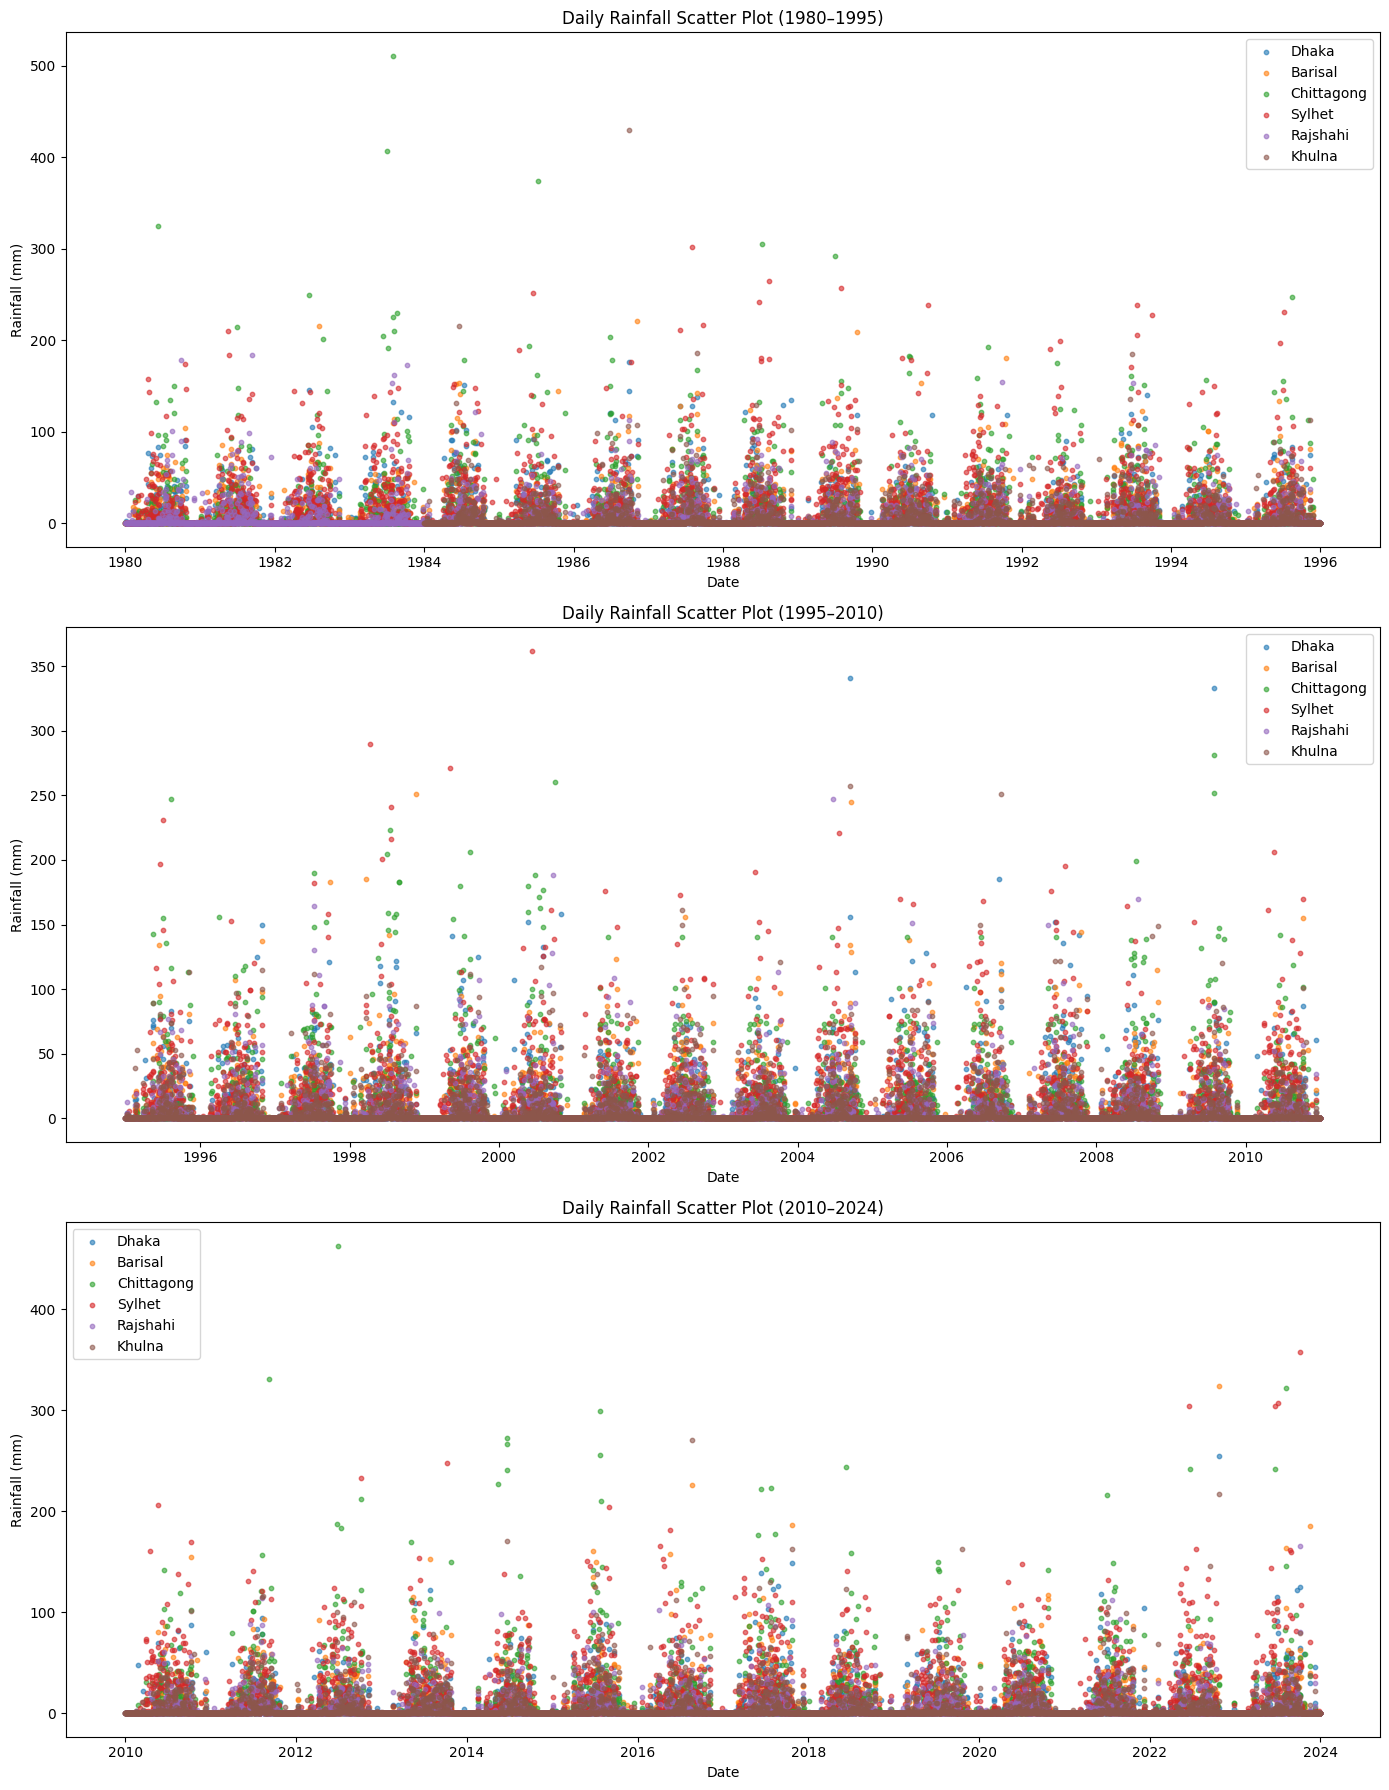

In [19]:
stations = ['Dhaka', 'Barisal', 'Chittagong', 'Sylhet', 'Rajshahi', 'Khulna']

# Define time periods
time_periods = [
    (1980, 1995, "Daily Rainfall Scatter Plot (1980–1995)"),
    (1995, 2010, "Daily Rainfall Scatter Plot (1995–2010)"),
    (2010, 2024, "Daily Rainfall Scatter Plot (2010–2024)")
]

# Create 3 subplots (one row, three columns)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18), sharex=False)

# Loop through each time period
for i, (start, end, title) in enumerate(time_periods):
    ax = axes[i]
    df_fil = df_new[(df_new['year'] >= start) & (df_new['year'] <= end)]

    for station in stations:
        df_station = (df_fil[df_fil['Station'] == station]
                      .groupby('Date')['Rainfall']
                      .sum()
                      .reset_index())

        ax.scatter(df_station['Date'], df_station['Rainfall'], s=10, label=station, alpha=0.6)

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Rainfall (mm)")
    ax.legend()

plt.tight_layout()
plt.show()
